https://github.com/NathanHashkes/machine_learning_ex2

Libraries (don't change)

In [ ]:
# https://github.com/NathanHashkes/machine_learning_ex2

!pip -q install torchinfo

from dataclasses import dataclass
from typing import List, Callable, Optional, Tuple

import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchinfo import summary

from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
%matplotlib inline


Device (don't change)

In [3]:

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
use_amp = (DEVICE == "cuda")

print(f"Using device: {DEVICE}")
print(f"Mixed precision (AMP): {use_amp}")

Using device: cpu
Mixed precision (AMP): False


Data (don't change)

In [4]:

class DataManager:
    def __init__(self, dataset_class, root: str = "./data", val_fraction: float = 0.1,
                 batch_size: int = 32, seed: int = 42):
        self.dataset_class = dataset_class
        self.root = root
        self.val_fraction = val_fraction
        self.batch_size = batch_size
        self.seed = seed

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1918,), (0.3483,))
        ])

    def get_loaders(self) -> Tuple[DataLoader, DataLoader, DataLoader]:
        full_train = self.dataset_class(root=self.root, train=True,
                                        download=True, transform=self.transform)
        test_ds = self.dataset_class(root=self.root, train=False,
                                     download=True, transform=self.transform)

        val_size = int(len(full_train) * self.val_fraction)
        train_size = len(full_train) - val_size

        generator = torch.Generator().manual_seed(self.seed)
        train_ds, val_ds = random_split(full_train, [train_size, val_size], generator=generator)

        train_loader = DataLoader(train_ds, batch_size=self.batch_size,
                                  shuffle=True, num_workers=2, pin_memory=True)
        val_loader   = DataLoader(val_ds,   batch_size=self.batch_size,
                                  shuffle=False, num_workers=2, pin_memory=True)
        test_loader  = DataLoader(test_ds,  batch_size=self.batch_size,
                                  shuffle=False, num_workers=2, pin_memory=True)

        print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
        return train_loader, val_loader, test_loader

Configurations (don't change)

In [5]:

@dataclass
class LayerSpec:
    out_dim: int
    activation: Callable[[torch.Tensor], torch.Tensor] = F.relu
    dropout: float = 0.0
    batch_norm: bool = True
    weight_decay: float = 0.0

@dataclass
class ModelConfig:
    input_dim: Tuple[int, int, int] = (1, 28, 28)
    num_classes: int = 10
    layers: List[LayerSpec] = None

@dataclass
class TrainConfig:
    batch_size: int = 64
    epochs: int = 100
    lr: float = 1e-4
    patience: int = 15
    min_delta: float = 1e-4
    val_fraction: float = 0.1
    seed: int = 42


Model

In [6]:

class MLPFromConfig(nn.Module):
    def __init__(self, config: ModelConfig):
        super().__init__()
        flat_dim = config.input_dim[0] * config.input_dim[1] * config.input_dim[2]
        self.layers_specs = config.layers
        layers = []
        prev_dim = flat_dim

        for i, spec in enumerate(config.layers):
            linear = nn.Linear(prev_dim, spec.out_dim)

            layers.append(linear)
            if spec.batch_norm:
                layers.append(nn.BatchNorm1d(spec.out_dim))
            if spec.dropout > 0:
                layers.append(nn.Dropout(spec.dropout))
            layers.append(spec.activation())
            prev_dim = spec.out_dim

        # Final classifier layer
        self.final_linear = nn.Linear(prev_dim, config.num_classes)
        layers.append(self.final_linear)

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)
        return self.net(x)

    def get_layer_params(self):
        param_groups = []
        for i, spec in enumerate(self.layers_specs):
            linear_layer = self.net[i * (4 if spec.batch_norm or spec.dropout > 0 else 3)]
            pass
        return self.layers_specs

Early Stopping (don't change)

In [7]:

class EarlyStopping:
    def __init__(self, patience: int = 10, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.should_stop = False

    def __call__(self, val_loss: float) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

Trainer (don't change)

In [8]:

class Trainer:
    def __init__(self, model: nn.Module, config: TrainConfig):
        self.model = model.to(DEVICE)
        self.config = config
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = self._build_optimizer()
        self.scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
        self.early_stopping = EarlyStopping(patience=config.patience,
                                            min_delta=config.min_delta)

        self.history = {"train_loss": [], "train_acc": [],
                        "val_loss": [], "val_acc": []}

    def _build_optimizer(self):

        # Collect all Linear layers in the order they appear
        linear_layers = []
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Linear):
                linear_layers.append((name, module))

        param_groups = []

        for i, spec in enumerate(self.model.layers_specs):
            name, layer = linear_layers[i]
            param_groups.append({
                'params': layer.parameters(),
                'weight_decay': spec.weight_decay
            })

        final_name, final_layer = linear_layers[-1]
        param_groups.append({
            'params': final_layer.parameters(),
            'weight_decay': 0.0
        })

        return torch.optim.SGD(param_groups, momentum=0.9, nesterov=True, lr=self.config.lr)

    def _train_epoch(self, loader: DataLoader):
        self.model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for data, target in loader:
            data, target = data.to(DEVICE), target.to(DEVICE)

            self.optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp):
                output = self.model(data)
                loss = self.criterion(output, target)

            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.item() * data.size(0)
            correct += (output.argmax(1) == target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    @torch.no_grad()
    def _eval_epoch(self, loader: DataLoader):
        self.model.eval()
        total_loss = 0.0
        correct = 0
        total = 0

        for data, target in loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=use_amp):
                output = self.model(data)
                loss = self.criterion(output, target)

            total_loss += loss.item() * data.size(0)
            correct += (output.argmax(1) == target).sum().item()
            total += data.size(0)

        return total_loss / total, correct / total

    def fit(self, train_loader: DataLoader, val_loader: DataLoader):
        print("🚀 Starting training...\n")
        for epoch in range(1, self.config.epochs + 1):
            train_loss, train_acc = self._train_epoch(train_loader)
            val_loss, val_acc     = self._eval_epoch(val_loader)

            self.history["train_loss"].append(train_loss)
            self.history["train_acc"].append(train_acc)
            self.history["val_loss"].append(val_loss)
            self.history["val_acc"].append(val_acc)

            print(f"Epoch {epoch:3d} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

            if self.early_stopping(val_loss):
                print(f"\n🛑 Early stopping triggered at epoch {epoch}")
                break

        print("\n✅ Training complete!")

    @torch.no_grad()
    def evaluate(self, loader: DataLoader):
        return self._eval_epoch(loader)

    @torch.no_grad()
    def predict_all(self, loader: DataLoader):
        self.model.eval()
        all_preds, all_targets = [], []
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            logits = self.model(x)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(y.numpy())
        return np.concatenate(all_preds), np.concatenate(all_targets)


    def save(self, path: str = "mlp_best.pt"):
        torch.save(self.model.state_dict(), path)
        print(f"💾 Model saved to {path}")



Run (do change)

In [ ]:
# installing MLflow
!pip install mlflow

# imports
import mlflow
import mlflow.sklearn
from mlflow import log_param, log_metric
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import itertools

# Define MLFlow experiment
EXPERIMENT_NAME = "neural_network_hyperparam"
mlflow.set_experiment(EXPERIMENT_NAME)

# Params (similar to how we did it in exercise 1)
# This way we can easily change or add numbers and compare performances
learning_rate_params = [1e-2,1e-4]
epochs_params = [100]
layer_amount_params = [1,3]
neurons_per_layer_params = [128]
dropout_params = [0.1,0.3]
batch_norm_params = [False, True]
activation_params = [nn.ReLU]
batch_size_params = [64,128]
patience_params = [5]

param_grid = list(itertools.product(learning_rate_params, epochs_params, layer_amount_params, neurons_per_layer_params, dropout_params,
                                    batch_norm_params, activation_params, batch_size_params, patience_params))

mlflow.end_run() # To prevent errors from past runs

# Running and logging the performance and training of all expriments
# Later on, we will pick the best one and "recreate" it.
experiment_id = 0
for (learning_rate, epochs_amount, layer_amount, neurons_per_layer, dropout, batch_norm, activation, batch_size, patience) in param_grid:
  with mlflow.start_run():
    experiment_id += 1
    # Log expriment number
    mlflow.log_param("experiment_number", experiment_id)
    # Log paramters
    mlflow.log_param("learning_rate", learning_rate)
    mlflow.log_param("epochs_amount", epochs_amount)
    mlflow.log_param("layer_amount", layer_amount)
    mlflow.log_param("neurons_per_layer", neurons_per_layer)
    mlflow.log_param("dropout", dropout)
    mlflow.log_param("batch_norm", batch_norm)
    mlflow.log_param("activation", activation.__name__)
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("patience", patience)

    train_cfg = TrainConfig(
      batch_size=batch_size,
      epochs=epochs_amount,
      lr=learning_rate,
      patience=patience,
      val_fraction=0.1
    )

    data_mgr = DataManager(
      dataset_class=datasets.KMNIST,
      val_fraction=train_cfg.val_fraction,
      batch_size=train_cfg.batch_size,
      seed=train_cfg.seed
    )

    train_loader, val_loader, test_loader = data_mgr.get_loaders()

    model_cfg = ModelConfig(
      layers=[
          LayerSpec(out_dim=neurons_per_layer,  dropout=dropout, batch_norm=batch_norm, activation = activation, weight_decay=5e-1) for x in range(layer_amount)
      ]
    )

    # Build model
    model = MLPFromConfig(model_cfg)
    print(f"\n--🟢 Starting experiment number {experiment_id}🟢--")
    print(summary(model, input_size=(1, 28, 28)))

    # Train model
    trainer = Trainer(model, train_cfg)
    trainer.fit(train_loader, val_loader)

    # predictions - for both test and train data
    test_preds, test_targets = trainer.predict_all(test_loader)
    train_preds, train_targets = trainer.predict_all(train_loader)

    # Calculate metrics
    average_type="macro"
    acc_test = accuracy_score(test_targets, test_preds)
    pre_test = precision_score(test_targets, test_preds, average=average_type)
    rec_test = recall_score(test_targets, test_preds, average=average_type)
    f1_test = f1_score(test_targets, test_preds, average=average_type)
    acc_train = accuracy_score(train_targets, train_preds)
    pre_train = precision_score(train_targets, train_preds, average=average_type)
    rec_train = recall_score(train_targets, train_preds, average=average_type)
    f1_train = f1_score(train_targets, train_preds, average=average_type)

    # Log metrics - for both test and train
    mlflow.log_metric("accuracy_test", acc_test)
    mlflow.log_metric("precision_score_test", pre_test)
    mlflow.log_metric("recall_score_test", rec_test)
    mlflow.log_metric("f1_score_test", f1_test)
    mlflow.log_metric("accuracy_train", acc_train)
    mlflow.log_metric("precision_score_train", pre_train)
    mlflow.log_metric("recall_score_train", rec_train)
    mlflow.log_metric("f1_score_train", f1_train)



# Recreating the best trainer  with the highest test accuracy -
# So the visualizations later on will be useful
df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])

best = df.sort_values("metrics.accuracy_test", ascending=False).iloc[0]

best_train_cfg = TrainConfig(
  batch_size=int(best["params.batch_size"]),
  epochs=int(best["params.epochs_amount"]),
  lr=float(best["params.learning_rate"]),
  patience=int(best["params.patience"]),
  val_fraction=0.1
)

best_data_mgr = DataManager(
  dataset_class=datasets.KMNIST,
  val_fraction=best_train_cfg.val_fraction,
  batch_size=best_train_cfg.batch_size,
  seed=best_train_cfg.seed
)

train_loader, val_loader, test_loader = best_data_mgr.get_loaders()

best_model_cfg = ModelConfig(
  layers=[
    LayerSpec(out_dim = int(best["params.neurons_per_layer"]),  dropout = float(best["params.dropout"]), batch_norm = best["params.batch_norm"],
              activation = nn.ReLU, weight_decay=5e-1) for x in range(int(best["params.layer_amount"]))
  ]
)
best_model = MLPFromConfig(best_model_cfg)
print(f"\n--🏆 Best model is model number {best["params.experiment_number"]}!🏆 --\nRecreating it:\n")
print(summary(best_model, input_size=(1, 28, 28)))
trainer = Trainer(best_model, best_train_cfg)
trainer.fit(train_loader, val_loader)
trainer.save("mlp_colab_best.pt")
mlflow.end_run()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.2/779.2 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 5.5 MB/s eta 0:00:00


2026/01/14 13:51:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/14 13:51:09 INFO mlflow.store.db.utils: Updating database tables
2026/01/14 13:51:09 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/14 13:51:09 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/14 13:51:09 INFO alembic.runtime.migration: Running upgrade  -> 451aebb31d03, add metric step
2026/01/14 13:51:09 INFO alembic.runtime.migration: Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
2026/01/14 13:51:09 INFO alembic.runtime.migration: Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
2026/01/14 13:51:09 INFO alembic.runtime.migration: Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
2026/01/14 13:51:10 INFO alembic.runtime.migration: Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
2026/01/14 13:51:10 INFO alembic.runtime.migration: Running 

Train: 54000 | Val: 6000 | Test: 10000

--🟢 Starting experiment number 1🟢--
Layer (type:depth-idx)                   Output Shape              Param #
MLPFromConfig                            [1, 10]                   --
├─Sequential: 1-1                        [1, 10]                   --
│    └─Linear: 2-1                       [1, 128]                  100,480
│    └─Dropout: 2-2                      [1, 128]                  --
│    └─ReLU: 2-3                         [1, 128]                  --
│    └─Linear: 2-4                       [1, 10]                   1,290
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.10
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.41
Estimated Total Size (MB): 0.41
🚀 Starting training...



/tmp/ipython-input-2705984033.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-2705984033.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipython-input-2705984033.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch   1 | Train Loss: 0.7786 Acc: 0.7764 | Val Loss: 0.5928 Acc: 0.8240
Epoch   2 | Train Loss: 0.5705 Acc: 0.8320 | Val Loss: 0.5709 Acc: 0.8227
Epoch   3 | Train Loss: 0.5186 Acc: 0.8454 | Val Loss: 0.5020 Acc: 0.8510
Epoch   4 | Train Loss: 0.4902 Acc: 0.8534 | Val Loss: 0.4777 Acc: 0.8588
Epoch   5 | Train Loss: 0.4675 Acc: 0.8604 | Val Loss: 0.4746 Acc: 0.8523
Epoch   6 | Train Loss: 0.4515 Acc: 0.8652 | Val Loss: 0.4324 Acc: 0.8717
Epoch   7 | Train Loss: 0.4363 Acc: 0.8679 | Val Loss: 0.4191 Acc: 0.8763
Epoch   8 | Train Loss: 0.4270 Acc: 0.8721 | Val Loss: 0.4210 Acc: 0.8787
Epoch   9 | Train Loss: 0.4175 Acc: 0.8739 | Val Loss: 0.4308 Acc: 0.8700
Epoch  10 | Train Loss: 0.4074 Acc: 0.8779 | Val Loss: 0.4468 Acc: 0.8638
Epoch  11 | Train Loss: 0.4013 Acc: 0.8796 | Val Loss: 0.4078 Acc: 0.8798
Epoch  12 | Train Loss: 0.3919 Acc: 0.8824 | Val Loss: 0.3905 Acc: 0.8820
Epoch  13 | Train Loss: 0.3880 Acc: 0.8837 | Val Loss: 0.4009 Acc: 0.8778
Epoch  14 | Train Loss: 0.3800 Acc: 0.

...

Epoch   1 | Train Loss: 2.0925 Acc: 0.3015 | Val Loss: 1.7850 Acc: 0.6598
Epoch   2 | Train Loss: 1.6982 Acc: 0.5808 | Val Loss: 1.4838 Acc: 0.7245
Epoch   3 | Train Loss: 1.4454 Acc: 0.6859 | Val Loss: 1.2524 Acc: 0.7833
Epoch   4 | Train Loss: 1.2475 Acc: 0.7473 | Val Loss: 1.0627 Acc: 0.8190
Epoch   5 | Train Loss: 1.0925 Acc: 0.7891 | Val Loss: 0.8968 Acc: 0.8518
Epoch   6 | Train Loss: 0.9700 Acc: 0.8228 | Val Loss: 0.7910 Acc: 0.8813
Epoch   7 | Train Loss: 0.8849 Acc: 0.8428 | Val Loss: 0.7164 Acc: 0.8957
Epoch   8 | Train Loss: 0.8320 Acc: 0.8550 | Val Loss: 0.6664 Acc: 0.9043
Epoch   9 | Train Loss: 0.8026 Acc: 0.8610 | Val Loss: 0.6450 Acc: 0.9077
Epoch  10 | Train Loss: 0.7849 Acc: 0.8627 | Val Loss: 0.6326 Acc: 0.9075
Epoch  11 | Train Loss: 0.7731 Acc: 0.8669 | Val Loss: 0.6095 Acc: 0.9113
Epoch  12 | Train Loss: 0.7663 Acc: 0.8668 | Val Loss: 0.5999 Acc: 0.9132
Epoch  13 | Train Loss: 0.7554 Acc: 0.8691 | Val Loss: 0.5922 Acc: 0.9142
Epoch  14 | Train Loss: 0.7495 Acc: 0.

/tmp/ipython-input-2705984033.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-2705984033.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipython-input-2705984033.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch   1 | Train Loss: 2.2442 Acc: 0.1808 | Val Loss: 2.0463 Acc: 0.4923
Epoch   2 | Train Loss: 2.0018 Acc: 0.3791 | Val Loss: 1.8481 Acc: 0.6383
Epoch   3 | Train Loss: 1.8220 Acc: 0.5177 | Val Loss: 1.6706 Acc: 0.6897
Epoch   4 | Train Loss: 1.6680 Acc: 0.6028 | Val Loss: 1.5179 Acc: 0.7233
Epoch   5 | Train Loss: 1.5311 Acc: 0.6586 | Val Loss: 1.3707 Acc: 0.7485
Epoch   6 | Train Loss: 1.4102 Acc: 0.7011 | Val Loss: 1.2699 Acc: 0.7725
Epoch   7 | Train Loss: 1.3000 Acc: 0.7364 | Val Loss: 1.1489 Acc: 0.7958
Epoch   8 | Train Loss: 1.1962 Acc: 0.7634 | Val Loss: 1.0537 Acc: 0.8168
Epoch   9 | Train Loss: 1.1105 Acc: 0.7891 | Val Loss: 0.9719 Acc: 0.8312
Epoch  10 | Train Loss: 1.0383 Acc: 0.8048 | Val Loss: 0.8997 Acc: 0.8453
Epoch  11 | Train Loss: 0.9679 Acc: 0.8256 | Val Loss: 0.8309 Acc: 0.8665
Epoch  12 | Train Loss: 0.9122 Acc: 0.8411 | Val Loss: 0.7738 Acc: 0.8805
Epoch  13 | Train Loss: 0.8592 Acc: 0.8559 | Val Loss: 0.7120 Acc: 0.8987
Epoch  14 | Train Loss: 0.8184 Acc: 0.

/tmp/ipython-input-2705984033.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-2705984033.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipython-input-2705984033.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch   1 | Train Loss: 2.0380 Acc: 0.3542 | Val Loss: 1.7664 Acc: 0.5895
Epoch   2 | Train Loss: 1.6581 Acc: 0.6111 | Val Loss: 1.4903 Acc: 0.7038
Epoch   3 | Train Loss: 1.4360 Acc: 0.7021 | Val Loss: 1.3021 Acc: 0.7525
Epoch   4 | Train Loss: 1.2720 Acc: 0.7499 | Val Loss: 1.1515 Acc: 0.7888
Epoch   5 | Train Loss: 1.1393 Acc: 0.7848 | Val Loss: 1.0375 Acc: 0.8137
Epoch   6 | Train Loss: 1.0291 Acc: 0.8107 | Val Loss: 0.9385 Acc: 0.8352
Epoch   7 | Train Loss: 0.9343 Acc: 0.8335 | Val Loss: 0.8533 Acc: 0.8503
Epoch   8 | Train Loss: 0.8522 Acc: 0.8525 | Val Loss: 0.7673 Acc: 0.8697
Epoch   9 | Train Loss: 0.7811 Acc: 0.8694 | Val Loss: 0.7072 Acc: 0.8843
Epoch  10 | Train Loss: 0.7168 Acc: 0.8875 | Val Loss: 0.6379 Acc: 0.9072
Epoch  11 | Train Loss: 0.6621 Acc: 0.9018 | Val Loss: 0.5943 Acc: 0.9148
Epoch  12 | Train Loss: 0.6185 Acc: 0.9131 | Val Loss: 0.5517 Acc: 0.9257
Epoch  13 | Train Loss: 0.5808 Acc: 0.9222 | Val Loss: 0.5189 Acc: 0.9302
Epoch  14 | Train Loss: 0.5540 Acc: 0.

Visuazize the train


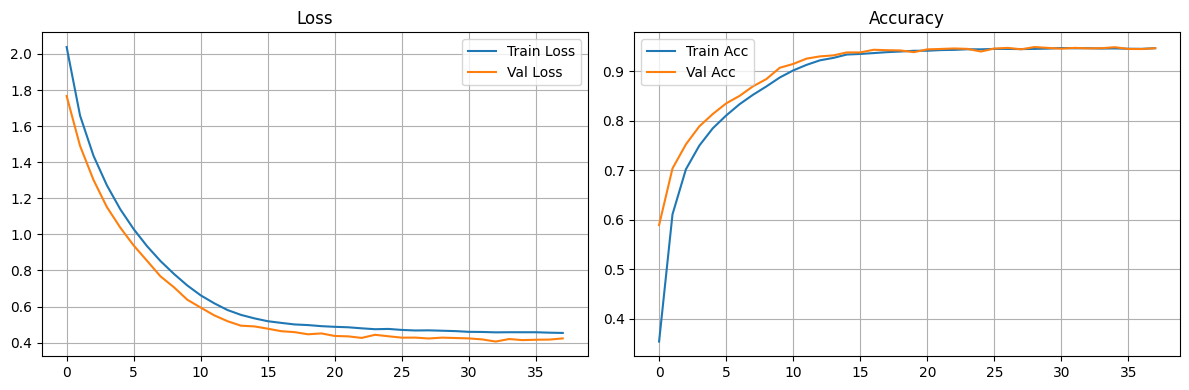

In [10]:

history = trainer.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"],   label="Val Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"],   label="Val Acc")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()




Visualized the test (do change)

/tmp/ipython-input-2705984033.py:72: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


🏆 Test Loss: 0.6477 | Test Accuracy: 0.8769


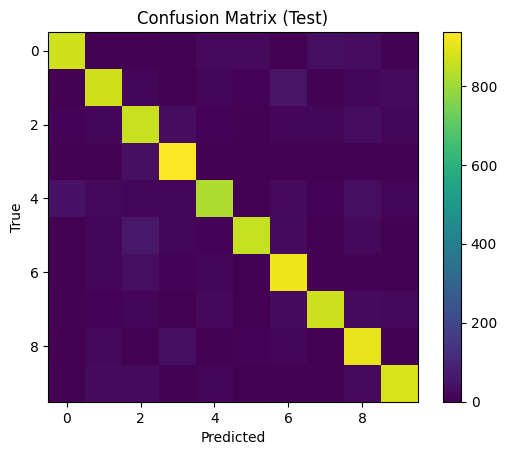

Classification report (Test):
              precision    recall  f1-score   support

           0     0.9197    0.8700    0.8941      1000
           1     0.8716    0.8690    0.8703      1000
           2     0.8043    0.8590    0.8308      1000
           3     0.8906    0.9360    0.9127      1000
           4     0.8817    0.8200    0.8497      1000
           5     0.9332    0.8520    0.8907      1000
           6     0.8454    0.9130    0.8779      1000
           7     0.9191    0.8630    0.8901      1000
           8     0.8277    0.9030    0.8637      1000
           9     0.8975    0.8840    0.8907      1000

    accuracy                         0.8769     10000
   macro avg     0.8791    0.8769    0.8771     10000
weighted avg     0.8791    0.8769    0.8771     10000



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# entire test result
test_loss, test_acc = trainer.evaluate(test_loader)
print(f"🏆 Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# predictions
preds, targets = trainer.predict_all(test_loader)

# confusion matrix
cm = confusion_matrix(targets, preds)
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

# per-class report
print("Classification report (Test):")
print(classification_report(targets, preds, digits=4))

# Save and print excel
from google.colab import files
df = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME])
df = df.drop(columns=[col for col in df.columns if "time" in col.lower()], errors="ignore")
df.to_excel("nathan_hashkes_ex2.xlsx", index=False)
files.download("nathan_hashkes_ex2.xlsx")

